In [2]:
# هام: يجب تشغيل هذا الجزء أولاً من أجل استيراد بيانات Kaggle
# يمكنك حذف هذا الجزء بعد استيراد البيانات
# ملاحظة: بيئة التشغيل هنا تختلف عن بيئة Kaggle، لذلك قد تكون بعض المكتبات غير متوفرة

import kagglehub  # استيراد مكتبة kagglehub التي تتيح تحميل بيانات Kaggle بسهولة

# تحميل مجموعة بيانات صور الأحجار الكريمة من Kaggle وتخزين المسار المحلي الناتج
lsind18_gemstones_images_path = kagglehub.dataset_download("lsind18/gemstones-images")

# طباعة المسار المحلي للمجلد الذي تم فيه تحميل البيانات
print(lsind18_gemstones_images_path)

# طباعة تأكيد بأن عملية الاستيراد تمت بنجاح
print("Data source import complete.")  # تم استيراد مصدر البيانات بنجاح

/kaggle/input/gemstones-images
Data source import complete.


In [3]:
# تثبيت أو تحديث مكتبة transformers من Hugging Face
# هذه المكتبة تُستخدم لتحميل واستخدام نماذج اللغة المدربة مسبقًا مثل BERT وGPT وغيرها
!pip install -U transformers

# تثبيت مجموعة مكتبات مهمة للعمل مع نماذج تعلم الآلة:
# - evaluate: مكتبة لتقييم أداء النماذج باستخدام مقاييس مثل الدقة والدقة التراكمية
# - transformers: كما سبق، للتعامل مع النماذج المدربة مسبقًا
# - datasets: لتحميل مجموعات البيانات الجاهزة من Hugging Face
# - mlflow: لتتبع التجارب والنماذج وتنظيمها
!pip install -q evaluate transformers datasets mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.8/733.8 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.2/196.2 kB 19.4 MB/s eta 0:00:00


In [4]:
# --- الاستيرادات الأساسية ---

# تجاهل التحذيرات لتفادي ازدحام المخرجات
import warnings

warnings.filterwarnings("ignore")

# إدارة الذاكرة (لتحرير الموارد غير المستخدمة يدويًا)
import gc

# استيراد مكتبات علم البيانات وتحليلها
import numpy as np  # للتعامل مع المصفوفات والحسابات العددية
import pandas as pd  # لتحليل البيانات وإنشاء جداول بيانات

# أدوات مساعدة مختلفة
import itertools  # لإنشاء تراكيب تكرارية مثل حاصل الضرب الديكارتي
from collections import Counter  # لحساب تكرار العناصر في القائمة

# مكتبة الرسومات البيانية
import matplotlib.pyplot as plt  # لإنشاء الرسوم البيانية والتصوير البصري للبيانات

# استيراد دوال تقييم أداء النموذج من scikit-learn
from sklearn.metrics import (
    accuracy_score,  # لحساب الدقة
    roc_auc_score,  # لحساب المساحة تحت منحنى ROC
    confusion_matrix,  # لإنشاء مصفوفة الالتباس
    classification_report,  # لتوليد تقرير تصنيف شامل
    f1_score,  # لحساب مقياس F1
)

# مكتبة HuggingFace Evaluate لتقييم النماذج باستخدام أدوات جاهزة
import evaluate

# تحميل فئات البيانات والصور من مكتبة HuggingFace datasets
from datasets import Dataset, Image

# استيراد الأدوات الرئيسية للتدريب باستخدام نموذج ViT (Vision Transformer)
from transformers import (
    TrainingArguments,  # لتحديد إعدادات التدريب مثل عدد الدورات ومجلد الحفظ
    Trainer,  # أداة التدريب الجاهزة من HuggingFace
    ViTImageProcessor,  # لمعالجة الصور قبل إدخالها إلى نموذج ViT
    ViTForImageClassification,  # نموذج التصنيف باستخدام ViT
    DefaultDataCollator,  # لتجميع البيانات بطريقة افتراضية أثناء التدريب
)

# استيراد مكتبات PyTorch
import torch  # المكتبة الأساسية لبناء النماذج
from torch.utils.data import DataLoader  # لتحميل البيانات على دفعات أثناء التدريب

# استيراد التحويلات الأساسية من torchvision لتحسين وتعديل الصور
from torchvision.transforms import (
    CenterCrop,  # قص الجزء الأوسط من الصورة
    Compose,  # لتجميع عدة تحويلات معًا
    Normalize,  # لتطبيع الصور
    RandomRotation,  # لتدوير الصور بشكل عشوائي
    RandomResizedCrop,  # لقص الصور بحجم عشوائي
    RandomHorizontalFlip,  # لقلب الصورة أفقيًا بشكل عشوائي
    RandomAdjustSharpness,  # لتعديل حدة الصورة عشوائيًا
    Resize,  # لتغيير حجم الصورة
    ToTensor,  # لتحويل الصورة إلى مصفوفة رقمية (Tensor)
)

True
3219 3219
Dataset({
    features: ['image', 'label'],
    num_rows: 3219
})


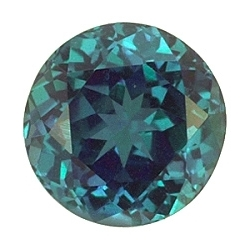

In [5]:
# مرجع تحميل الصور من Hugging Face:
# https://huggingface.co/docs/datasets/image_load

# إنشاء قاموس (غير مستخدم هنا فعليًا)
image_dict = {}

# استيراد الأدوات اللازمة
from pathlib import Path  # للتعامل مع المسارات والملفات
from tqdm import tqdm  # لإظهار شريط تقدم عند تنفيذ الحلقات

# إنشاء قائمتين لتخزين مسارات الصور والتصنيفات الخاصة بها
file_names = []
labels = []

# التحقق مما إذا كان المسار يحتوي على بيانات الصور بالفعل
print(
    Path("/kaggle/input/gemstones-images/").exists()
)  # يجب أن يُرجع True إذا كانت البيانات موجودة

# البحث عن جميع ملفات الصور داخل مجلدات التصنيفات (بنية المجلد: فئة/اسم_الملف.jpg)
for file in sorted((Path("/kaggle/input/gemstones-images/").glob("*/*/*.jpg"))):
    file_names.append(str(file))  # حفظ المسار الكامل للصورة
    label = str(file).split("/")[
        -2
    ]  # استخراج اسم الفئة (اسم المجلد الذي يحتوي على الصورة)
    labels.append(label)

# طباعة عدد الصور وعدد التصنيفات التي تم استخراجها
print(len(file_names), len(labels))

# تحويل البيانات إلى كائن Dataset من مكتبة Hugging Face
# يحتوي على عمود "image" للمسار و "label" للتصنيف
dataset = Dataset.from_dict({"image": file_names, "label": labels}).cast_column(
    "image", Image()
)  # تحويل عمود الصور ليتم التعامل معه كصورة فعلية

# طباعة معلومات عن مجموعة البيانات الناتجة
print(dataset)

# عرض أول صورة من مجموعة البيانات (كائن صورة قابل للعرض)
dataset[0]["image"]

In [6]:
labels[:5]

['Alexandrite', 'Alexandrite', 'Alexandrite', 'Alexandrite', 'Almandine']

هذا السطر:

```python
labels[:5]
```

يعني:

📌 **عرض أول 5 عناصر من قائمة التصنيفات `labels`**، والتي تحتوي على أسماء الفئات المستخرجة من أسماء مجلدات الصور.

### مثال على الناتج المحتمل:

إذا كانت مجلدات الصور بهذا الشكل:

```
/kaggle/input/gemstones-images/diamond/image1.jpg  
/kaggle/input/gemstones-images/ruby/image2.jpg  
/kaggle/input/gemstones-images/emerald/image3.jpg  
```

فإن الإخراج سيكون مثل:

```python
['diamond', 'diamond', 'emerald', 'emerald', 'ruby']
```

💡 هذا مفيد للتحقق من أن التصنيفات قد تم استخراجها بشكل صحيح من مسارات الصور.


In [7]:
# إنشاء قائمة تحتوي على التصنيفات الفريدة فقط (إزالة التكرارات)
labels_list = list(set(labels))

# إنشاء قاموسين:
# label2id: يحوّل اسم التصنيف إلى رقم (معرّف)
# id2label: يحوّل الرقم (المعرّف) إلى اسم التصنيف
label2id, id2label = dict(), dict()

# ربط كل تصنيف برقم فريد باستخدام enumerate
for i, label in enumerate(labels_list):
    label2id[label] = i  # تعيين رقم لكل اسم تصنيف
    id2label[i] = label  # تعيين اسم التصنيف لكل رقم

# طباعة القاموسين للتأكد من الربط بين الأرقام والتصنيفات
print(id2label, "\n\n", label2id)

{0: 'Tourmaline', 1: 'Onyx Green', 2: 'Sapphire Pink', 3: 'Chrome Diopside', 4: 'Chrysoberyl', 5: 'Quartz Lemon', 6: 'Alexandrite', 7: 'Sapphire Purple', 8: 'Almandine', 9: 'Diamond', 10: 'Sphene', 11: 'Cats Eye', 12: 'Danburite', 13: 'Citrine', 14: 'Scapolite', 15: 'Quartz Beer', 16: 'Chalcedony Blue', 17: 'Larimar', 18: 'Lapis Lazuli', 19: 'Andradite', 20: 'Amethyst', 21: 'Carnelian', 22: 'Quartz Rose', 23: 'Opal', 24: 'Hiddenite', 25: 'Variscite', 26: 'Zoisite', 27: 'Spessartite', 28: 'Garnet Red', 29: 'Pearl', 30: 'Quartz Smoky', 31: 'Topaz', 32: 'Chrysoprase', 33: 'Blue Lace Agate', 34: 'Jasper', 35: 'Spodumene', 36: 'Quartz Rutilated', 37: 'Coral', 38: 'Jade', 39: 'Rhodolite', 40: 'Chrysocolla', 41: 'Ruby', 42: 'Moonstone', 43: 'Emerald', 44: 'Pyrite', 45: 'Aventurine Green', 46: 'Kunzite', 47: 'Bixbite', 48: 'Serpentine', 49: 'Tsavorite', 50: 'Tigers Eye', 51: 'Aventurine Yellow', 52: 'Onyx Black', 53: 'Hessonite', 54: 'Sapphire Blue', 55: 'Spinel', 56: 'Morganite', 57: 'Dumorti

In [8]:
# تقسيم البيانات إلى بيانات تدريب واختبار باستخدام دالة train_test_split
# يتم تخصيص 20% من البيانات للاختبار و80% للتدريب
dataset = dataset.train_test_split(test_size=0.2)

# استخراج بيانات التدريب من المجموعة المقسمة
train_data = dataset["train"]

# استخراج بيانات الاختبار من المجموعة المقسمة
test_data = dataset["test"]


### لماذا نستخدم هذا؟

* `del dataset`: يحذف المتغير `dataset` الذي لم نعد بحاجة له بعد تقسيمه إلى `train_data` و `test_data`.
* `gc.collect()`: يطلب من Python تنفيذ تنظيف الذاكرة فورًا، وهو مفيد خصوصًا عند التعامل مع مجموعات بيانات كبيرة لتقليل استهلاك الذاكرة.

💡 يُستخدم هذا غالبًا في البيئات التي تكون فيها الموارد محدودة مثل Kaggle Notebooks أو Google Colab.


In [9]:
# حذف كائن dataset من الذاكرة لتحرير المساحة
del dataset

# استدعاء جامع القمامة (garbage collector) لتحرير الذاكرة يدويًا
gc.collect()

126

ملاحظات مهمة:
.convert("RGB") تضمن أن الصور تحتوي على 3 قنوات فقط (لون أحمر وأخضر وأزرق)، وهو ما يحتاجه نموذج ViT.

استخدام التحسينات العشوائية مثل RandomRotation وRandomAdjustSharpness مفيد جدًا في تقوية أداء النموذج وتقليل الاعتماد على بيانات معينة (Data Augmentation).

هذه التحويلات ضرورية لأن نموذج ViT يتطلب إدخال صور بتنسيق ومعالجة معينة تتوافق مع ما تم تدريبه عليه.

هل ترغب في شرح كيفية تطبيق هذه التحويلات على بيانات train_data و test_data؟

In [10]:
# تحديد اسم النموذج الذي سيتم استخدامه (نموذج ViT من Google مدرب مسبقًا على ImageNet-21k)
model_str = "google/vit-base-patch16-224-in21k"

# تحميل معالج الصور الخاص بالنموذج (لإجراء التحويلات اللازمة لتجهيز الصور للنموذج)
processor = ViTImageProcessor.from_pretrained(model_str)

# استخراج قيم المتوسط والانحراف المعياري التي استخدمها النموذج أثناء التدريب
image_mean, image_std = processor.image_mean, processor.image_std

# استخراج الحجم المطلوب للصورة (الارتفاع) من الإعدادات
size = processor.size["height"]
print("Size: ", size)

# إنشاء خطوة التطبيع (Normalize) باستخدام نفس القيم التي درب بها النموذج
normalize = Normalize(mean=image_mean, std=image_std)

# التحويلات التي تُطبّق على صور التدريب (مع بعض التحسينات العشوائية لزيادة التنوع)
_train_transforms = Compose(
    [
        Resize((size, size)),  # تغيير حجم الصورة إلى الحجم المطلوب
        RandomRotation(15),  # تدوير الصورة بشكل عشوائي حتى 15 درجة
        RandomAdjustSharpness(2),  # تعديل الحدة بشكل عشوائي
        ToTensor(),  # تحويل الصورة إلى مصفوفة Tensor
        normalize,  # تطبيع الصورة باستخدام mean و std
    ]
)

# التحويلات التي تُطبّق على صور التحقق (validation) — بدون تحسينات عشوائية
_val_transforms = Compose(
    [
        Resize((size, size)),  # تغيير حجم الصورة
        ToTensor(),  # تحويل الصورة إلى Tensor
        normalize,  # تطبيع الصورة
    ]
)


# دالة تطبّق تحويلات التدريب على كل صورة داخل مجموعة بيانات التدريب
def train_transforms(examples):
    examples["pixel_values"] = [
        _train_transforms(image.convert("RGB")) for image in examples["image"]
    ]
    return examples


# دالة تطبّق تحويلات التحقق على كل صورة داخل مجموعة بيانات التحقق
def val_transforms(examples):
    examples["pixel_values"] = [
        _val_transforms(image.convert("RGB")) for image in examples["image"]
    ]
    return examples

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Size:  224


ماذا يحدث هنا؟
عند استخدام set_transform من مكتبة Hugging Face Datasets:

يتم تطبيق التحويل ديناميكيًا (عند كل استدعاء) بدلًا من حفظ الصور المعدّلة في الذاكرة.

يحافظ على ذاكرة أقل وأداء أكثر كفاءة، خصوصًا مع مجموعات بيانات كبيرة.

يصبح بإمكانك تمرير البيانات الجاهزة مباشرة إلى النموذج دون الحاجة لتحويلها يدويًا لاحقًا.

هل ترغب في الانتقال الآن إلى إعداد النموذج والتدريب باستخدام Trainer؟

In [11]:
# تعيين التحويلات المخصصة على بيانات التدريب
# بحيث يتم تطبيق train_transforms تلقائيًا عند تحميل كل عينة
train_data.set_transform(train_transforms)

# تعيين التحويلات المخصصة على بيانات التحقق (الاختبار)
# بحيث يتم تطبيق val_transforms تلقائيًا عند تحميل كل عينة
test_data.set_transform(val_transforms)

لماذا هذه الدالة مهمة؟
مكتبة transformers.Trainer تسمح بتمرير collate_fn مخصصة.

هذه الدالة تضمن أن البيانات تُجمّع بشكل صحيح وتكون جاهزة للإدخال في النموذج (أي بشكل batch).

تُستخدم عند تحميل البيانات بحيث يتم تحزيم الصور والتصنيفات معًا في دفعات بكفاءة.

هل ترغب أن أساعدك في إعداد الكائن Trainer أو TrainingArguments الآن؟

In [12]:
# دالة لتجميع مجموعة من العينات في دفعة واحدة (batch)
# تُستخدم عند تحميل البيانات في DataLoader أو Trainer


def collate_fn(examples):
    # دمج الصور في مصفوفة واحدة (Batch) باستخدام torch.stack
    # كل صورة تم تحويلها مسبقًا إلى Tensor وتخزينها في "pixel_values"
    pixel_values = torch.stack([example["pixel_values"] for example in examples])

    # تحويل التصنيفات النصية إلى أرقام باستخدام قاموس label2id ثم تحويلها إلى Tensor
    labels = torch.tensor([label2id[example["label"]] for example in examples])

    # إرجاع قاموس يحتوي على الصور والتصنيفات بصيغة مفهومة للنموذج
    return {
        "pixel_values": pixel_values,  # بيانات الصور (batch)
        "labels": labels,  # التصنيفات الرقمية (batch)
    }

ملاحظات مهمة:
num_labels=len(labels_list) يخبر النموذج بعدد الفئات المختلفة التي يجب أن يصنف إليها الصور.

model.config.id2label و label2id يستخدمان في مراحل التقييم وتفسير نتائج النموذج.

الدالة model.num_parameters(only_trainable=True) تُظهر عدد المعاملات التي سيتم تحديثها أثناء التدريب (وليس الثابتة).

هل تريد الآن المساعدة في إعداد TrainingArguments أو بدء التدريب باستخدام Trainer؟

In [13]:
# تحميل نموذج ViT للتصنيف الصوري من مكتبة Hugging Face
# يتم تحديد عدد المخرجات (عدد التصنيفات) باستخدام عدد الفئات الفريدة
model = ViTForImageClassification.from_pretrained(
    model_str, num_labels=len(labels_list)
)

# ربط أرقام التصنيفات بأسمائها داخل إعدادات النموذج (مهم لتفسير المخرجات وتقييمها)
model.config.id2label = id2label  # من الرقم إلى الاسم (مثلاً: 0 → 'diamond')
model.config.label2id = label2id  # من الاسم إلى الرقم (مثلاً: 'diamond' → 0)

# طباعة عدد المعاملات القابلة للتدريب في النموذج (بالملايين)
# مفيد لفهم حجم النموذج والتأكد من أن جميع الطبقات مفتوحة للتدريب
print(model.num_parameters(only_trainable=True) / 1e6)

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


85.865559


ملاحظات إضافية:
predictions.argmax(axis=1) تقوم باختيار الفئة التي حصلت على أعلى درجة من النموذج لكل عينة.

label_ids هي الفئات الحقيقية من مجموعة التحقق.

هذه الدالة سيتم تمريرها إلى كائن Trainer لتُستخدم تلقائيًا في تقييم النموذج بعد كل مرحلة تدريب.

هل تريد الآن إعداد كائن Trainer وبدء عملية التدريب؟

In [14]:
# تحميل مقياس الدقة (Accuracy) من مكتبة evaluate التابعة لـ Hugging Face
accuracy = evaluate.load("accuracy")


# تعريف دالة لحساب مقاييس التقييم التي سيتم استخدامها أثناء التحقق والتجريب
def compute_metrics(eval_pred):
    # استخراج التنبؤات (قيم الإخراج من النموذج قبل تطبيق softmax)
    predictions = eval_pred.predictions

    # ملاحظة: يمكن تطبيق softmax يدويًا إذا لزم الأمر (معلق في الكود أدناه)
    # predictions = np.exp(predictions)/np.exp(predictions).sum(axis=1, keepdims=True)

    # استخراج القيم الحقيقية (التصنيفات الفعلية)
    label_ids = eval_pred.label_ids

    # حساب الدقة (Accuracy) من خلال مقارنة التوقعات مع القيم الفعلية
    # يتم اختيار الفئة صاحبة أعلى احتمالية عبر argmax
    acc_score = accuracy.compute(
        predictions=predictions.argmax(axis=1), references=label_ids
    )["accuracy"]

    # إرجاع نتيجة الدقة ضمن قاموس (يمكن لاحقًا إضافة المزيد من المقاييس مثل F1, Precision...)
    return {"accuracy": acc_score}

ملاحظات مهمة:
save_total_limit=1 مفيد جدًا عندما تعمل في بيئة مثل Kaggle أو Google Colab لتوفير المساحة.

load_best_model_at_end=True يعني أن النموذج النهائي سيكون الأفضل حسب مقياس accuracy (المتبع تلقائيًا إذا لم تحدد metric_for_best_model).

report_to="mlflow" يُستخدم لتسجيل النتائج تلقائيًا في نظام MLflow إذا كنت قد قمت بإعداده مسبقًا.

هل ترغب الآن في إنشاء كائن Trainer وبدء التدريب؟

In [15]:
# تحديد اسم المقياس الرئيسي الذي سيتم تتبعه أثناء التدريب
metric_name = "accuracy"

# تحديد اسم مجلد إخراج النموذج (يُستخدم لحفظ النموذج المدرب والنتائج)
model_name = "gemstones_image_detection"

# تحديد عدد دورات التدريب (epochs)
num_train_epochs = 60

# إعداد كائن TrainingArguments وهو مسؤول عن تحديد جميع إعدادات التدريب
args = TrainingArguments(
    output_dir=model_name,  # مسار حفظ النموذج ونتائج التدريب
    logging_dir="./logs",  # مسار حفظ سجلات التدريب
    eval_strategy="epoch",  # إجراء التحقق من الأداء بعد كل دورة (epoch)
    learning_rate=1e-5,  # معدل التعلم (كلما قلّ كان التدريب أكثر استقرارًا)
    per_device_train_batch_size=32,  # حجم الدفعة أثناء التدريب لكل جهاز (GPU/CPU)
    per_device_eval_batch_size=8,  # حجم الدفعة أثناء التحقق (evaluation)
    num_train_epochs=num_train_epochs,  # عدد الدورات الكلية للتدريب
    weight_decay=0.02,  # معدل تقليل الأوزان لتجنب فرط التعلّم (regularization)
    warmup_steps=50,  # عدد الخطوات التي يتم فيها تسخين معدل التعلم تدريجيًا
    remove_unused_columns=False,  # الحفاظ على جميع أعمدة البيانات وعدم تجاهل غير المستخدمة
    save_strategy="epoch",  # حفظ النموذج بعد كل دورة تدريبية
    load_best_model_at_end=True,  # تحميل أفضل نموذج تم التحقق من أدائه في النهاية
    save_total_limit=1,  # حفظ نموذج واحد فقط (الأفضل) لتقليل استهلاك المساحة
    report_to="mlflow",  # إرسال نتائج التدريب إلى MLflow لتتبع التجارب
)

ملاحظات مهمة:
Trainer يتكفل تلقائيًا بجميع المهام مثل: التدريب، حفظ النموذج، التحقق من الأداء، تسجيل المقاييس.

tokenizer=processor يُستخدم هنا لأنه يتعامل مع الصور وليس النصوص، لكنه ضروري لتوافق بعض واجهات Hugging Face.

data_collator يضمن أن الدفعات تُمرر بشكل صحيح للنموذج، خصوصًا وأنك تستخدم تحويلات مخصصة.



In [16]:
# إنشاء كائن Trainer من مكتبة Hugging Face لتولي عملية التدريب والتقييم تلقائيًا

trainer = Trainer(
    model,  # النموذج الذي سيتم تدريبه (ViT في حالتك)
    args,  # إعدادات التدريب التي تم تحديدها مسبقًا في TrainingArguments
    train_dataset=train_data,  # مجموعة بيانات التدريب
    eval_dataset=test_data,  # مجموعة بيانات التحقق (validation)
    data_collator=collate_fn,  # دالة لتجميع البيانات على شكل دفعات (batch)
    compute_metrics=compute_metrics,  # دالة لحساب مقاييس التقييم (مثل الدقة)
    tokenizer=processor,  # المعالج المسؤول عن تجهيز الصور للنموذج (هنا ViTImageProcessor)
)

✅ شرح باللغة العربية:
هذا السطر يقوم بتنفيذ عملية التقييم (evaluation) على مجموعة بيانات التحقق (eval_dataset والتي عيّنتها سابقًا بـ test_data) باستخدام النموذج المدرب حاليًا.

In [17]:
trainer.evaluate()

{'eval_loss': 4.468003749847412,
 'eval_model_preparation_time': 0.0027,
 'eval_accuracy': 0.013975155279503106,
 'eval_runtime': 10.5649,
 'eval_samples_per_second': 60.956,
 'eval_steps_per_second': 7.667}


هذا السطر يقوم بتنفيذ **عملية التقييم (evaluation)** على مجموعة بيانات التحقق (`eval_dataset` والتي عيّنتها سابقًا بـ `test_data`) باستخدام النموذج المدرب حاليًا.

---

### 📌 ما يحدث داخليًا:

* يقوم `Trainer` بتمرير بيانات التحقق إلى النموذج.
* يتم حساب التنبؤات (predictions) من النموذج.
* يتم مقارنة التنبؤات مع التصنيفات الحقيقية.
* يتم استخدام دالة `compute_metrics` التي قمت بتعريفها لحساب **الدقة (accuracy)** أو أي مقاييس أخرى.
* يتم إرجاع قاموس يحتوي على نتائج التقييم.

---

### 🖥 مثال ناتج محتمل:

```python
{'eval_loss': 0.587, 'eval_accuracy': 0.874, 'eval_runtime': 12.4, ...}
```

---


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time,Accuracy
1,No log,4.403609,0.002700,0.072981
2,No log,4.291713,0.002700,0.237578
3,No log,4.168214,0.002700,0.377329
4,No log,4.038076,0.002700,0.486025
5,No log,3.897892,0.002700,0.600932
6,No log,3.754628,0.002700,0.653727
7,4.063500,3.629027,0.002700,0.697205
8,4.063500,3.510897,0.002700,0.720497
9,4.063500,3.400720,0.002700,0.745342
10,4.063500,3.295470,0.002700,0.754658




هذا السطر يبدأ عملية **تدريب النموذج** باستخدام الإعدادات التي قمت بتحديدها مسبقًا داخل `TrainingArguments`، ويستخدم البيانات الموجودة في `train_dataset`.

---

### 🔁 ما يحدث أثناء التدريب:

1. **البيانات**:

   * يتم تحميل بيانات التدريب على دفعات (`batch`) باستخدام `data_collator`.

2. **التحسين**:

   * يتم حساب الخسارة (loss) وتحديث أوزان النموذج باستخدام الخوارزمية (مثل Adam).
   * يتم تطبيق تحسينات تدريجية على النموذج بناءً على الخطأ في التنبؤات.

3. **التحقق بعد كل دورة**:

   * لأنك اخترت `eval_strategy="epoch"`، سيقوم `Trainer` بتقييم النموذج على مجموعة الاختبار بعد كل دورة (`epoch`).

4. **حفظ النموذج**:

   * النموذج يتم حفظه في نهاية كل دورة لأنك استخدمت `save_strategy="epoch"`.
   * في النهاية، سيتم تحميل **أفضل نموذج** تلقائيًا لأنك استخدمت `load_best_model_at_end=True`.

---

### 📌 مخرجات الشاشة أثناء التدريب:

* ستظهر لك معلومات مثل:

  * `epoch` (رقم الدورة)
  * `train_loss` (الخسارة أثناء التدريب)
  * `eval_accuracy` (الدقة أثناء التحقق)
  * `eval_loss` (الخسارة أثناء التحقق)
  * `runtime` و `samples_per_second` وغيرها...

---



In [19]:
trainer.evaluate()

{'eval_loss': 1.6238858699798584,
 'eval_model_preparation_time': 0.0027,
 'eval_accuracy': 0.84472049689441,
 'eval_runtime': 8.9988,
 'eval_samples_per_second': 71.565,
 'eval_steps_per_second': 9.001,
 'epoch': 60.0}



بعد الانتهاء من التدريب (`trainer.train()`)، يقوم هذا السطر بتقييم النموذج المدرب على مجموعة بيانات التحقق `eval_dataset` (والتي حددتها مسبقًا بـ `test_data`).

---

### ⚙️ ماذا يفعل `trainer.evaluate()` بالتفصيل:

* يُمرر بيانات التحقق إلى النموذج المدرب.
* يُحسب **الخسارة (eval\_loss)**.
* تُستخدم دالة `compute_metrics` لحساب مقاييس إضافية مثل:

  * ✅ **الدقة (accuracy)** (أنت قمت بتعريفها).
* تُرجع النتائج في شكل قاموس (`dict`) يحتوي على المقاييس.

---

### 🖥 مثال على ناتج الإخراج:

```python
{'eval_loss': 0.4831, 'eval_accuracy': 0.9125, 'eval_runtime': 10.5, 'eval_samples_per_second': 42.3, ...}
```

---

### ملاحظات:

* إذا كانت الدقة منخفضة، قد يكون السبب:

  * عدد قليل من البيانات.
  * عدم توازن في الفئات.
  * الحاجة لتحسين تحويل الصور (augmentation).
* يمكنك طباعة مصفوفة الالتباس (confusion matrix) أو التنبؤات الخاطئة لمعرفة التفاصيل.

---


In [20]:
outputs = trainer.predict(test_data)
print(outputs.metrics)

{'test_loss': 1.6238858699798584, 'test_model_preparation_time': 0.0027, 'test_accuracy': 0.84472049689441, 'test_runtime': 8.8596, 'test_samples_per_second': 72.689, 'test_steps_per_second': 9.143}




هذا السطرين يقومان بـ:

---

### 1. `trainer.predict(test_data)`

* يُطلب من `Trainer` توليد **تنبؤات** باستخدام النموذج المدرب على بيانات `test_data`.
* يتم حساب:

  * `predictions`: تنبؤات النموذج (الاحتمالات أو الدرجات)
  * `label_ids`: القيم الحقيقية (الفعلية)
  * `metrics`: المقاييس المحسوبة عبر `compute_metrics`

---

### 2. `print(outputs.metrics)`

* يقوم بطباعة المقاييس التي تم حسابها مثل:

  * `test_accuracy`: دقة النموذج
  * `test_loss`: خسارة النموذج على بيانات الاختبار
  * `test_runtime`: مدة التنبؤ
  * `samples_per_second`: السرعة

---

### 📦 مثال على المخرجات:

```python
{
  'test_loss': 0.42,
  'test_accuracy': 0.88,
  'test_runtime': 12.34,
  'test_samples_per_second': 40.5,
  'test_steps_per_second': 5.1
}
```

---



Accuracy: 0.8447
F1 Score: 0.8279


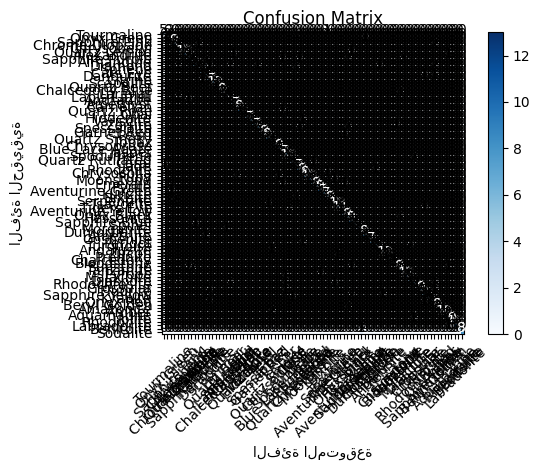

In [21]:
# استخراج القيم الحقيقية والتنبؤات النهائية
y_true = outputs.label_ids  # التصنيفات الحقيقية
y_pred = outputs.predictions.argmax(1)  # التنبؤات النهائية (الفئة ذات أعلى احتمال)


# تعريف دالة لرسم مصفوفة الالتباس
def plot_confusion_matrix(cm, classes, title="Confusion Matrix", cmap=plt.cm.Blues):
    """
    ترسم مصفوفة الالتباس بشكل بصري.

    Parameters:
        cm: مصفوفة الالتباس المحسوبة عبر scikit-learn.
        classes: قائمة بأسماء الفئات (مثل ['diamond', 'ruby', 'emerald']).
        title: عنوان الرسم البياني.
        cmap: نظام الألوان المستخدم في العرض.
    """
    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()  # شريط الألوان الجانبي
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)  # تسميات المحور الأفقي
    plt.yticks(tick_marks, classes)  # تسميات المحور العمودي

    fmt = ".0f"  # تنسيق الأرقام داخل المصفوفة
    thresh = cm.max() / 2.0  # لتحديد لون النص داخل الخلايا
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
        )

    plt.ylabel("الفئة الحقيقية")
    plt.xlabel("الفئة المتوقعة")
    plt.tight_layout()
    plt.show()


# حساب الدقة ودرجة F1
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(
    y_true, y_pred, average="macro"
)  # 'macro' تعني حساب المتوسط بين جميع الفئات بالتساوي

# عرض النتائج
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

# إنشاء مصفوفة الالتباس
cm = confusion_matrix(y_true, y_pred)

# رسم مصفوفة الالتباس
plot_confusion_matrix(cm, labels_list)

In [22]:
trainer.save_model()

In [ ]:
from transformers import pipeline

pipe = pipeline("image-classification", model=model_name, device=0)

In [ ]:
image = test_data[1]["image"]
image


* هذا يقوم بجلب **الصورة الثانية** (الموقع `[1]`) من بيانات الاختبار `test_data` (والتي تحتوي على صور مصنفة).
* ثم يتم عرض الصورة نفسها داخل نوتبوك Jupyter أو بيئة تفاعلية مثل Google Colab أو Kaggle.

---

### ✅ ماذا تحتوي `test_data[1]`؟

```python
{
  'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224 at 0x...>,
  'label': 'emerald'
}
```

---

### لعرض الصورة مع عنوانها:

```python
import matplotlib.pyplot as plt

image = test_data[1]["image"]
label = test_data[1]["label"]

plt.imshow(image)
plt.title(f"True Label: {label}")
plt.axis('off')
plt.show()
```

---


In [ ]:
pipe(image)
test_data[1]["label"]

# Send model to Huggingface

In [ ]:
# finally, save the model to Huggingface
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from huggingface_hub import HfApi

api = HfApi()
repo_id = f"joud2000/{model_name}"
try:
    api.create_repo(repo_id)
    print(f"Repo {repo_id} created")
except:
    print(f"Repo {repo_id} already exists")

In [ ]:
api.upload_folder(
    folder_path=model_name, path_in_repo=".", repo_id=repo_id, repo_type="model"
)